# Forcasting with foundational models

## Libraries

In [28]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
path = str(Path.cwd().parent)
print(path)
sys.path.insert(1, path)

import numpy as np
import pandas as pd
import skforecast

print(skforecast.__version__)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/home/joaquin/Documents/GitHub/skforecast
0.21.0


In [29]:
# Libraries
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from skforecast.datasets import fetch_dataset
from skforecast.preprocessing import (
    reshape_series_wide_to_long,
    reshape_series_long_to_dict, 
)
from skforecast.foundational import ForecasterFoundational, FoundationalModel
from skforecast.model_selection import (
    TimeSeriesFold,
    backtesting_foundational
)
from skforecast.plot import set_dark_theme

## Input data

The class <code>[ForecasterFoundational](../api/forecasterfoundational.html)</code> allows to model and forecast multiple scenarios with a single model. The input data allowed is:

In [30]:
# DataFrame wide to long
# ==============================================================================
data = fetch_dataset(name="items_sales")
display(data.head(3))

print("DataFrame wide to long:")
series_long = reshape_series_wide_to_long(data=data)
display(series_long.head(3))

╭─────────────────────── items_sales ───────────────────────╮
│ Description:                                              │
│ Simulated time series for the sales of 3 different items. │
│                                                           │
│ Source:                                                   │
│ Simulated data.                                           │
│                                                           │
│ URL:                                                      │
│ https://raw.githubusercontent.com/skforecast/skforecast-  │
│ datasets/main/data/simulated_items_sales.csv              │
│                                                           │
│ Shape: 1097 rows x 3 columns                              │
╰───────────────────────────────────────────────────────────╯

,item_1,item_2,item_3
date,,,
2012-01-01,8.253175,21.047727,19.429739
2012-01-02,22.777826,26.578125,28.009863
2012-01-03,27.549099,31.751042,32.078922


DataFrame wide to long:


value
series_id datetime             
item_1    2012-01-01   8.253175
          2012-01-02  22.777826
          2012-01-03  27.549099

In [31]:
# Load time series
# ==============================================================================
display(series_long.reset_index().head(3))

print("DataFrame long to dict:")
print("")
series_dict = reshape_series_long_to_dict(
    data      = series_long.reset_index(),
    series_id = 'series_id',
    index     = 'datetime',
    values    = 'value',
    freq      = 'D'
)

print(series_dict.keys())
print("")
print(series_dict['item_1'].head(3))

,series_id,datetime,value
0,item_1,2012-01-01,8.253175
1,item_1,2012-01-02,22.777826
2,item_1,2012-01-03,27.549099


DataFrame long to dict:

dict_keys(['item_1', 'item_2', 'item_3'])

2012-01-01     8.253175
2012-01-02    22.777826
2012-01-03    27.549099
Freq: D, Name: item_1, dtype: float64


In [32]:
# Split data into train-test
# ==============================================================================
end_train = '2014-07-15 23:59:00'
series_long_train = series_long.loc[series_long.index.get_level_values('datetime') <= end_train, :].copy()
series_long_test  = series_long.loc[series_long.index.get_level_values('datetime') > end_train, :].copy()

In [33]:
# Description of each partition
# ==============================================================================
for sid in series_long.index.levels[0]:
    print(f"{sid}:")
    try:
        train_sub = series_long_train.loc[sid]
        print(
            f"\tTrain: len={len(train_sub)}, {train_sub.index[0]} --- {train_sub.index[-1]}"
        )
    except IndexError:
        print("\tTrain: len=0")
    try:
        test_sub = series_long_test.loc[sid]
        print(
            f"\tTest : len={len(test_sub)}, {test_sub.index[0]} --- {test_sub.index[-1]}"
        )
    except IndexError:
        print("\tTest : len=0")

item_1:
	Train: len=927, 2012-01-01 00:00:00 --- 2014-07-15 00:00:00
	Test : len=170, 2014-07-16 00:00:00 --- 2015-01-01 00:00:00
item_2:
	Train: len=927, 2012-01-01 00:00:00 --- 2014-07-15 00:00:00
	Test : len=170, 2014-07-16 00:00:00 --- 2015-01-01 00:00:00
item_3:
	Train: len=927, 2012-01-01 00:00:00 --- 2014-07-15 00:00:00
	Test : len=170, 2014-07-16 00:00:00 --- 2015-01-01 00:00:00


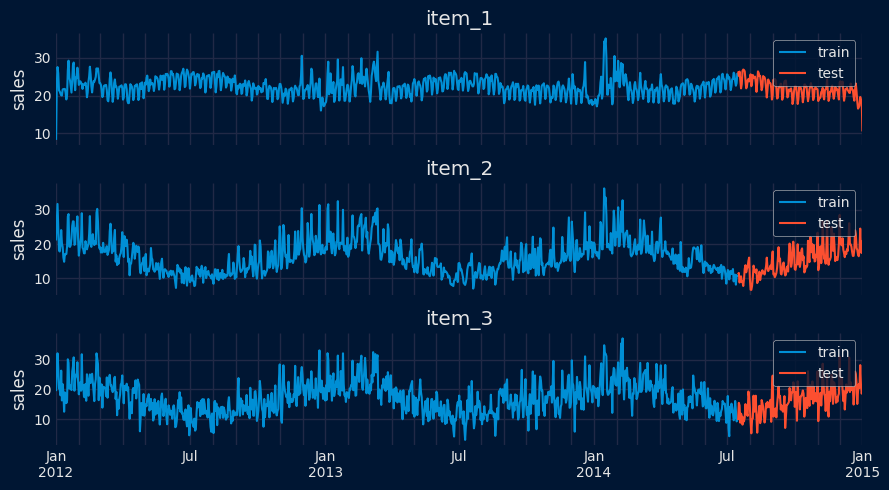

In [34]:
# Plot time series
# ==============================================================================
set_dark_theme()
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(9, 5), sharex=True)

for i, sid in enumerate(series_long.index.levels[0]):
    series_long_train.loc[sid, 'value'].plot(ax=axes[i], label='train')
    series_long_test.loc[sid, 'value'].plot(ax=axes[i], label='test')
    axes[i].set_title(sid)
    axes[i].set_ylabel('sales')
    axes[i].set_xlabel('')
    axes[i].legend(loc='upper right')

fig.tight_layout()
plt.show();

## ForecasterFoundational

In [35]:
# Create and train ForecasterFoundational
# ==============================================================================
estimator = FoundationalModel(model="autogluon/chronos-2-small")
forecaster = ForecasterFoundational(estimator = estimator)
forecaster.fit(series=series_long_train)
forecaster

╭────────────────────────────────── InputTypeWarning ──────────────────────────────────╮
│ Passing a DataFrame (either wide or long format) as `series` requires additional     │
│ internal transformations, which can increase computational time. It is recommended   │
│ to use a dictionary of pandas Series instead. For more details, see:                 │
│ https://skforecast.org/latest/user_guides/independent-multi-time-series-forecasting. │
│ html#input-data                                                                      │
│                                                                                      │
│ Category : skforecast.exceptions.InputTypeWarning                                    │
│ Location : /tmp/ipykernel_27400/1002830091.py:5                                      │
│ Suppress : warnings.simplefilter('ignore', category=InputTypeWarning)                │
╰──────────────────────────────────────────────────────────────────────────────────────╯

====================== 
ForecasterFoundational 
====================== 
Model: autogluon/chronos-2-small 
Context length: 2048 
Cross learning: False 
Series names: ['item_1', 'item_2', 'item_3'] 
Exogenous included: False 
Exogenous names: None 
Training range: {'item_1': [Timestamp('2012-01-01 00:00:00'), Timestamp('2014-07-15 00:00:00')], 'item_2': [Timestamp('2012-01-01 00:00:00'), Timestamp('2014-07-15 00:00:00')], 'item_3': [Timestamp('2012-01-01 00:00:00'), Timestamp('2014-07-15 00:00:00')]} 
Training index type: DatetimeIndex 
Training index frequency: <Day> 
Creation date: 2026-03-24 22:56:45 
Last fit date: 2026-03-24 22:56:45 
Skforecast version: 0.21.0 
Python version: 3.13.11 
Forecaster id: None

Two methods can be used to predict the next n steps: `predict()` or `predict_interval()`. The argument `levels` is used to indicate for which series estimate predictions. If `None` all series will be predicted.

In [36]:
# Predictions and prediction intervals
# ==============================================================================
steps = 24

# Predictions for item_1
predictions_item_1 = forecaster.predict(steps=steps, levels='item_1')
display(predictions_item_1.head(3))
print("")

# Interval predictions for item_1 and item_2
predictions_intervals = forecaster.predict_interval(
    steps    = steps,
    levels   = ['item_1', 'item_2'],
    interval = 0.9
)
display(predictions_intervals)

,level,pred
2014-07-16,item_1,25.393274
2014-07-17,item_1,25.141916
2014-07-18,item_1,25.119213


,level,pred,lower_bound,upper_bound
2014-07-16,item_1,25.393274,24.300997,26.557789
2014-07-16,item_2,10.694118,8.241322,14.236065
2014-07-17,item_1,25.141916,23.839874,26.399607
2014-07-17,item_2,10.868246,8.285328,14.759255
2014-07-18,item_1,25.119213,23.689602,26.470215
2014-07-18,item_2,10.891087,8.184448,15.031467
2014-07-19,item_1,23.781929,22.398643,25.186392
2014-07-19,item_2,10.985982,8.232456,14.881241
2014-07-20,item_1,21.413382,20.283951,22.789980
2014-07-20,item_2,11.076559,8.289808,15.048790


## Backtesting multiple series

As in the `predict` method, the `levels` at which [backtesting](../user_guides/backtesting.html) is performed must be indicated. The argument can also be set to `None` to perform backtesting at all levels. In addition to the individual metric(s) for each series, the aggregated value is calculated using the following methods:

+ **average**: the average (arithmetic mean) of all levels.

+ **weighted_average**: the average of the metrics weighted by the number of predicted values of each level.

+ **pooling**: the values of all levels are pooled and then the metric is calculated.

In [37]:
# Backtesting multiple time series
# ==============================================================================
cv = TimeSeriesFold(
         steps              = 24,
         initial_train_size = '2014-07-15 23:59:00',  # end_train
         fold_stride        = None,
         refit              = True
     )

metrics_levels, backtest_predictions = backtesting_foundational(
    forecaster            = forecaster,
    series                = series_long,
    exog                  = None,
    cv                    = cv,
    levels                = None,
    metric                = 'mean_absolute_error',
    add_aggregated_metric = True
)

print("Backtest metrics")
display(metrics_levels)
print("")
print("Backtest predictions")
backtest_predictions.head(4)


╭────────────────────────────────── InputTypeWarning ──────────────────────────────────╮
│ Passing a DataFrame (either wide or long format) as `series` requires additional     │
│ internal transformations, which can increase computational time. It is recommended   │
│ to use a dictionary of pandas Series instead. For more details, see:                 │
│ https://skforecast.org/latest/user_guides/independent-multi-time-series-forecasting. │
│ html#input-data                                                                      │
│                                                                                      │
│ Category : skforecast.exceptions.InputTypeWarning                                    │
│ Location : /tmp/ipykernel_27400/2676768587.py:10                                     │
│ Suppress : warnings.simplefilter('ignore', category=InputTypeWarning)                │
╰──────────────────────────────────────────────────────────────────────────────────────╯

  0%|          | 0/8 [00:00<?, ?it/s]

Backtest metrics


,levels,mean_absolute_error
0,item_1,0.796872
1,item_2,2.303262
2,item_3,2.960935
3,average,2.020357
4,weighted_average,2.020357
5,pooling,2.020357



Backtest predictions


,level,fold,pred
2014-07-16,item_1,0,25.393274
2014-07-16,item_2,0,10.694118
2014-07-16,item_3,0,12.005762
2014-07-17,item_1,0,25.141916


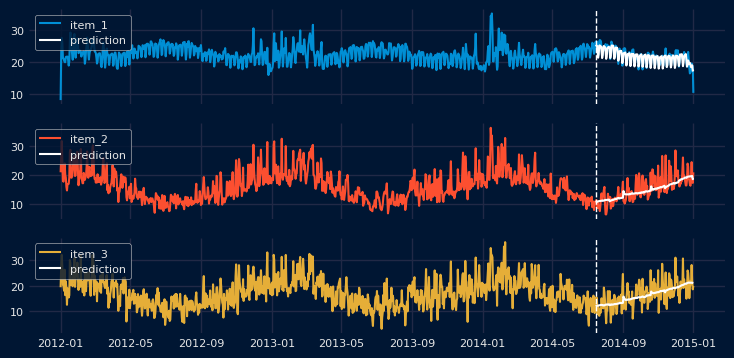

In [38]:
# Gráfico predicciones backtesting
# ==============================================================================
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
fig, axs = plt.subplots(3, 1, figsize=(8, 4), sharex=True)
for i, s in enumerate(series_dict.keys()):
    axs[i].plot(series_dict[s], label=series_dict[s].name, color=colors[i])
    axs[i].axvline(pd.to_datetime(end_train), color="white", linestyle="--", linewidth=1)
    try:
        axs[i].plot(
            backtest_predictions.loc[backtest_predictions["level"] == s, "pred"],
            label="prediction",
            color="white",
        )
    except:
        pass
    axs[i].legend(loc="upper left", fontsize=8)
    axs[i].tick_params(axis="both", labelsize=8)

## Exogenous variables in multi-series forecasting

Exogenous variables are predictors that are independent of the model being used for forecasting, and their future values must be known in order to include them in the prediction process. The class <code>[ForecasterRecursiveMultiSeries](../api/forecasterrecursivemultiseries.html)</code> supports multiple strategies for including exogenous variables:

- If `exog` is a **wide-format pandas DataFrame**, it must share the same index type as series. Each column represents a different exogenous variable, and the same values are applied to all time series.

- If `exog` is a **long-format pandas Series or DataFrame with a MultiIndex**, the first level contains the series IDs to which it belongs, and the second level must be a pandas `DatetimeIndex`. Each exogenous variable must be represented as a separate column.

- If `exog` is a **dictionary**, each key must correspond to a series ID, and each value must be either a named pandas `Series` or `DataFrame` with the same index type as `series`, or `None`. It is not required for all series to contain all exogenous variables, but data types must be consistent across series for each variable.

| Exog type              | Index requirements                                                      |
|:----------------------:|:------------------------------------------------------------------------|
| `Wide DataFrame`       | `pandas DatetimeIndex` or `RangeIndex` (all series same step/frequency) |
| `MultiIndex DataFrame` | First level `series_id`, second `datetime` (pandas `DatetimeIndex`)     |
| `dict`                 | `pandas DatetimeIndex` or `RangeIndex` (all series same step/frequency) |

<div class="admonition note" name="html-admonition" style="background: rgba(0,184,212,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00b8d4; border-color: #00b8d4; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00b8d4;"></i>
    <b style="color: #00b8d4;">&#9998 Note</b>
</p>

<p>
    The <code>ForecasterRecursiveMultiSeries</code> supports the use of distinct exogenous variables for each individual series. For a comprehensive guide on handling time series with varying lengths and exogenous variables, refer to the 
    <a href="../user_guides/multi-series-with-different-length-and-different_exog.html">Global Forecasting Models: Time Series with Different Lengths and Different Exogenous Variables</a>. 
    Additionally, for a more general overview of using exogenous variables in forecasting, please consult the 
    <a href="../user_guides/exogenous-variables.html">Exogenous Variables User Guide</a>.
</p>

</div>

In [39]:
# Generate the exogenous variable month
# ==============================================================================
exog_wide = pd.DataFrame(
    index = series_long.index.get_level_values('datetime').unique()
)
exog_wide['month'] = exog_wide.index.month

# Split data into train-val-test
# ==============================================================================
end_train = '2014-07-15 23:59:00'
exog_wide_train = exog_wide.loc[:end_train, :].copy()
exog_wide_test  = exog_wide.loc[end_train:, :].copy()

exog_wide_train.head(3)

,month
datetime,
2012-01-01,1
2012-01-02,1
2012-01-03,1


In [40]:
# Create and fit forecaster
# ==============================================================================
forecaster = ForecasterFoundational(estimator = estimator)

forecaster.fit(
    series = series_long_train, 
    exog   = exog_wide_train
)
forecaster

╭────────────────────────────────── InputTypeWarning ──────────────────────────────────╮
│ Passing a DataFrame (either wide or long format) as `series` requires additional     │
│ internal transformations, which can increase computational time. It is recommended   │
│ to use a dictionary of pandas Series instead. For more details, see:                 │
│ https://skforecast.org/latest/user_guides/independent-multi-time-series-forecasting. │
│ html#input-data                                                                      │
│                                                                                      │
│ Category : skforecast.exceptions.InputTypeWarning                                    │
│ Location : /tmp/ipykernel_27400/1324434816.py:5                                      │
│ Suppress : warnings.simplefilter('ignore', category=InputTypeWarning)                │
╰──────────────────────────────────────────────────────────────────────────────────────╯

====================== 
ForecasterFoundational 
====================== 
Model: autogluon/chronos-2-small 
Context length: 2048 
Cross learning: False 
Series names: ['item_1', 'item_2', 'item_3'] 
Exogenous included: True 
Exogenous names: month 
Training range: {'item_1': [Timestamp('2012-01-01 00:00:00'), Timestamp('2014-07-15 00:00:00')], 'item_2': [Timestamp('2012-01-01 00:00:00'), Timestamp('2014-07-15 00:00:00')], 'item_3': [Timestamp('2012-01-01 00:00:00'), Timestamp('2014-07-15 00:00:00')]} 
Training index type: DatetimeIndex 
Training index frequency: <Day> 
Creation date: 2026-03-24 22:56:49 
Last fit date: 2026-03-24 22:56:49 
Skforecast version: 0.21.0 
Python version: 3.13.11 
Forecaster id: None

If the `Forecaster` has been trained using exogenous variables, they should be provided during the prediction phase.

In [41]:
# Predict with exogenous variables
# ==============================================================================
predictions = forecaster.predict(steps=24, exog=exog_wide_test)
predictions.head(3)

,level,pred
2014-07-16,item_1,25.415682
2014-07-16,item_2,10.775169
2014-07-16,item_3,12.212003


To use exogenous variables in backtesting or hyperparameter tuning, they must be specified with the `exog` argument.

In [42]:
# Backtesting Multi-Series with exog
# ==============================================================================
cv = TimeSeriesFold(
         steps              = 24,
         initial_train_size = '2014-07-15 23:59:00',
         refit              = True,
     )

metrics_levels, backtest_predictions = backtesting_foundational(
    forecaster            = forecaster,
    series                = series_long,
    exog                  = exog_wide,
    cv                    = cv,
    levels                = None,
    metric                = 'mean_absolute_error',
    add_aggregated_metric = True
)

display(metrics_levels)
backtest_predictions.head(4)


╭────────────────────────────────── InputTypeWarning ──────────────────────────────────╮
│ Passing a DataFrame (either wide or long format) as `series` requires additional     │
│ internal transformations, which can increase computational time. It is recommended   │
│ to use a dictionary of pandas Series instead. For more details, see:                 │
│ https://skforecast.org/latest/user_guides/independent-multi-time-series-forecasting. │
│ html#input-data                                                                      │
│                                                                                      │
│ Category : skforecast.exceptions.InputTypeWarning                                    │
│ Location : /tmp/ipykernel_27400/3961106638.py:9                                      │
│ Suppress : warnings.simplefilter('ignore', category=InputTypeWarning)                │
╰──────────────────────────────────────────────────────────────────────────────────────╯

  0%|          | 0/8 [00:00<?, ?it/s]

,levels,mean_absolute_error
0,item_1,0.813805
1,item_2,2.294703
2,item_3,2.950858
3,average,2.019789
4,weighted_average,2.019789
5,pooling,2.019789


,level,fold,pred
2014-07-16,item_1,0,25.415682
2014-07-16,item_2,0,10.775169
2014-07-16,item_3,0,12.212003
2014-07-17,item_1,0,25.205822


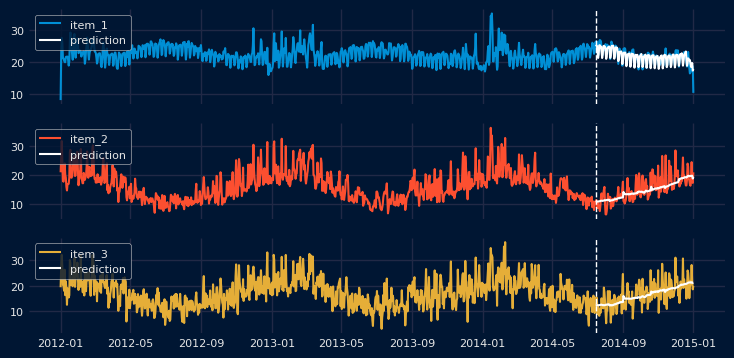

In [43]:
# Gráfico predicciones backtesting
# ==============================================================================
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
fig, axs = plt.subplots(3, 1, figsize=(8, 4), sharex=True)
for i, s in enumerate(series_dict.keys()):
    axs[i].plot(series_dict[s], label=series_dict[s].name, color=colors[i])
    axs[i].axvline(pd.to_datetime(end_train), color="white", linestyle="--", linewidth=1)
    try:
        axs[i].plot(
            backtest_predictions.loc[backtest_predictions["level"] == s, "pred"],
            label="prediction",
            color="white",
        )
    except:
        pass
    axs[i].legend(loc="upper left", fontsize=8)
    axs[i].tick_params(axis="both", labelsize=8)